In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10,6)


df = pd.read_csv("superstore_dataset.csv", encoding='latin1')

print("Dataset shape:", df.shape)
display(df.head())
df.info()


Dataset shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:

print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

#  missing values
print("\nMissing values per column:\n", df.isnull().sum())

if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

for col in ['Order Date', 'Ship Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'Order Date' in df.columns:
    df['Order Year'] = df['Order Date'].dt.year
    df['Order Month'] = df['Order Date'].dt.month
    df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

df['Profit Margin %'] = (df['Profit'] / df['Sales']).replace([np.inf, -np.inf], np.nan) * 100

display(df[['Sales','Profit','Profit Margin %']].describe().round(2))


Duplicates before: 0
Duplicates after: 0

Missing values per column:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


,Sales,Profit,Profit Margin %
count,9994.00,9994.00,9994.00
mean,229.86,28.66,12.03
std,623.25,234.26,46.68
min,0.44,-6599.98,-275.00
25%,17.28,1.73,7.50
50%,54.49,8.67,27.00
75%,209.94,29.36,36.25
max,22638.48,8399.98,50.00


State
California        457687.6315
New York          310876.2710
Texas             170188.0458
Washington        138641.2700
Pennsylvania      116511.9140
Florida            89473.7080
Illinois           80166.1010
Ohio               78258.1360
Michigan           76269.6140
Virginia           70636.7200
North Carolina     55603.1640
Indiana            53555.3600
Georgia            49095.8400
Kentucky           36591.7500
New Jersey         35764.3120
Arizona            35282.0010
Wisconsin          32114.6100
Colorado           32108.1180
Tennessee          30661.8730
Minnesota          29863.1500
Name: Sales, dtype: float64

C:\Users\PC\AppData\Local\Temp\ipykernel_3684\2898028925.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='viridis')


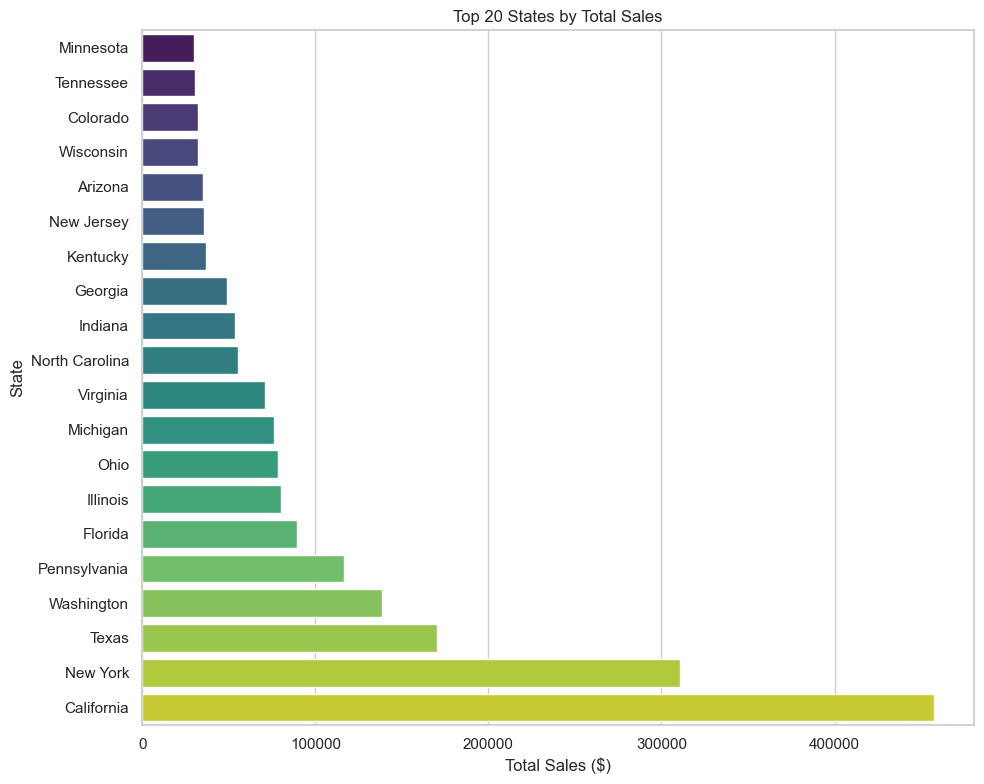

In [7]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
display(state_sales.head(20))

top_states = state_sales.head(20).sort_values()
plt.figure(figsize=(10,8))
sns.barplot(x=top_states.values, y=top_states.index, palette='viridis')
plt.title("Top 20 States by Total Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


New York -> Sales: $310,876 | Profit: $74,039
California -> Sales: $457,688 | Profit: $76,381


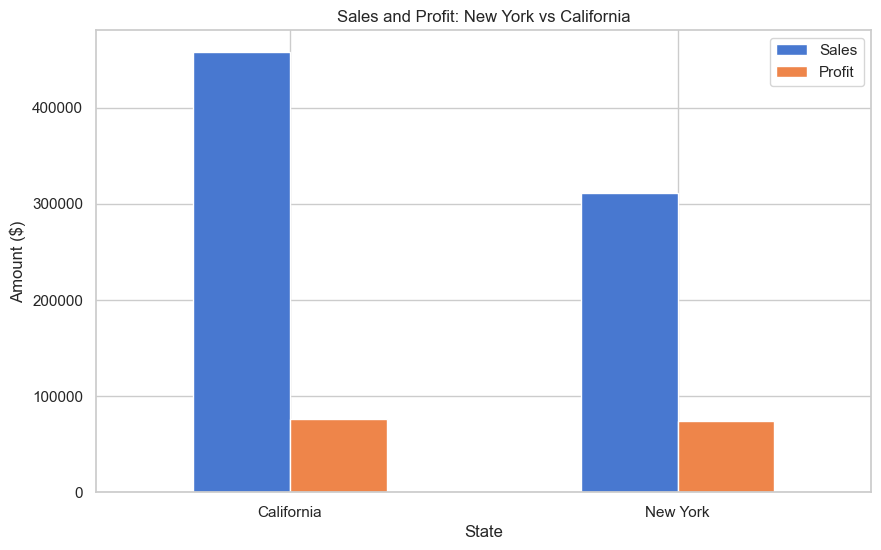

In [8]:
# Compare NY vs CA
for st in ['New York', 'California']:
    if st in df['State'].values:
        total_sales = df[df['State']==st]['Sales'].sum()
        total_profit = df[df['State']==st]['Profit'].sum()
        print(f"{st} -> Sales: ${total_sales:,.0f} | Profit: ${total_profit:,.0f}")
    else:
        print(f"{st} not in dataset")

states_comp = df[df['State'].isin(['New York','California'])].groupby('State')[['Sales','Profit']].sum()
states_comp.plot(kind='bar', rot=0)
plt.title("Sales and Profit: New York vs California")
plt.ylabel("Amount ($)")
plt.show()


,Sales,Profit,Profit Margin %
State,,,
District of Columbia,2865.02,1059.59,36.98
Delaware,27451.07,9977.37,36.35
Minnesota,29863.15,10823.19,36.24
Maine,1270.53,454.49,35.77
Arkansas,11678.13,4008.69,34.33
Indiana,53555.36,18382.94,34.33
Georgia,49095.84,16250.04,33.10
Montana,5589.35,1833.33,32.80
Rhode Island,22627.96,7285.63,32.20


C:\Users\PC\AppData\Local\Temp\ipykernel_3684\3753050686.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit Margin %', y=plot_df.index, data=plot_df, palette='coolwarm')


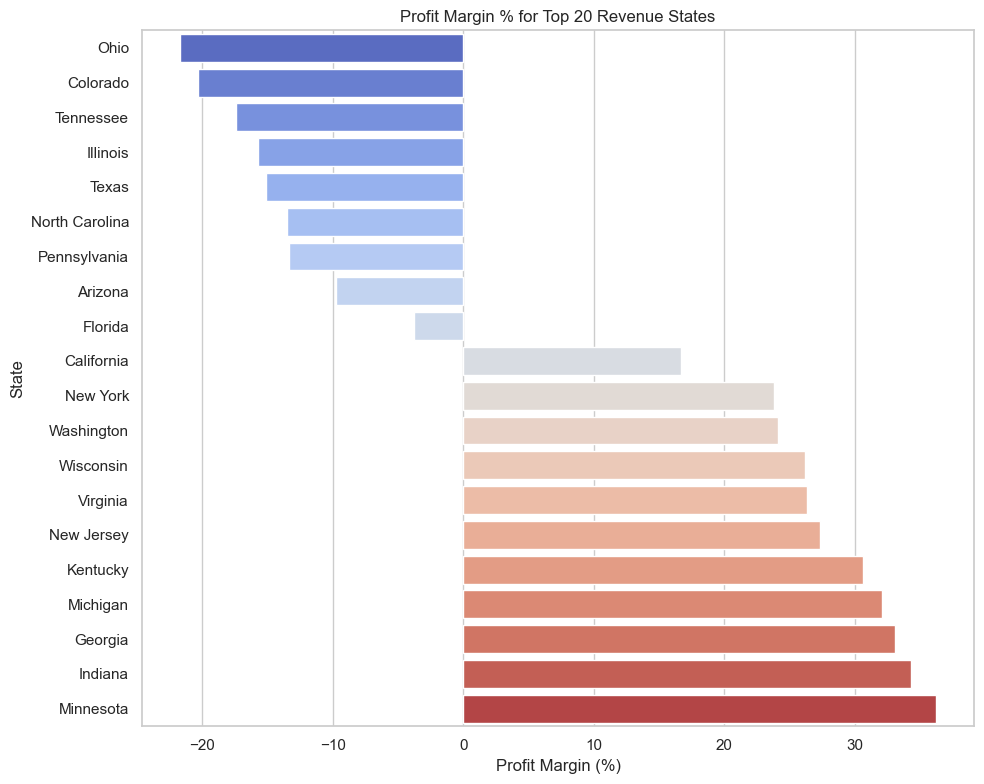

In [9]:
state_summary = df.groupby('State').agg({'Sales':'sum','Profit':'sum'}).assign(**{'Profit Margin %': lambda x: x['Profit']/x['Sales']*100})
state_summary = state_summary.sort_values('Profit Margin %', ascending=False)
display(state_summary.head(20).round(2))

# Plot Profit Margin for top 20 revenue states
top20_rev = state_sales.head(20).index
plot_df = state_summary.loc[top20_rev].sort_values('Profit Margin %')
plt.figure(figsize=(10,8))
sns.barplot(x='Profit Margin %', y=plot_df.index, data=plot_df, palette='coolwarm')
plt.xlabel("Profit Margin (%)")
plt.title("Profit Margin % for Top 20 Revenue States")
plt.tight_layout()
plt.show()


Top 20% customers (count=158) contribute $233,201 which is 81.4% of total profit


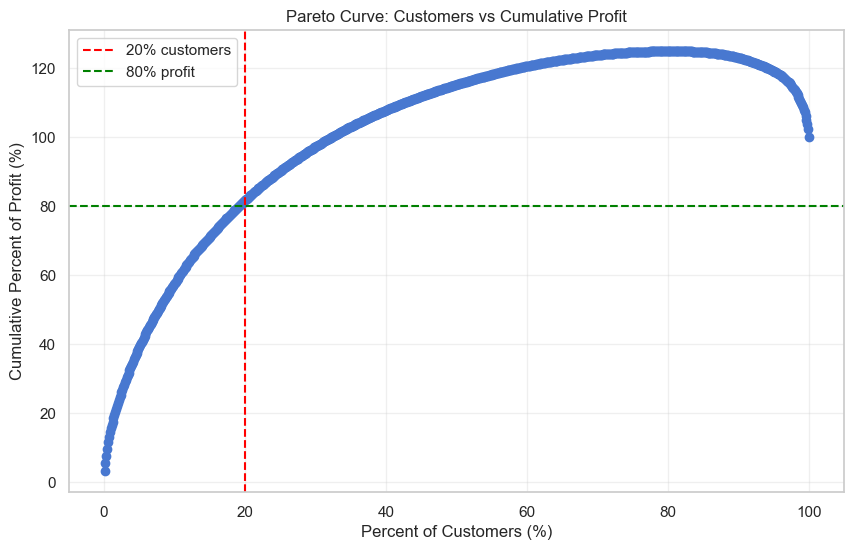

In [10]:
# Pareto: customers contributing to profit

cust_profit = df.groupby('Customer ID')['Profit'].sum().sort_values(ascending=False).reset_index()
cust_profit['cum_profit'] = cust_profit['Profit'].cumsum()
total_profit = cust_profit['Profit'].sum()
cust_profit['cum_profit_pct'] = cust_profit['cum_profit'] / total_profit

#  customer counts and percent of customers
cust_profit['customer_rank'] = np.arange(1, len(cust_profit)+1)
cust_profit['cust_pct'] = cust_profit['customer_rank'] / len(cust_profit)

# Find percent of profit from top 20% customers
top_20_cut = int(0.2 * len(cust_profit))
profit_from_top20pct = cust_profit.loc[:top_20_cut-1, 'Profit'].sum()
print(f"Top 20% customers (count={top_20_cut}) contribute ${profit_from_top20pct:,.0f} which is {profit_from_top20pct/total_profit*100:.1f}% of total profit")

# Plot cumulative curve
plt.figure(figsize=(10,6))
plt.plot(cust_profit['cust_pct']*100, cust_profit['cum_profit_pct']*100, marker='o')
plt.axvline(20, color='red', linestyle='--', label='20% customers')
plt.axhline(80, color='green', linestyle='--', label='80% profit')
plt.xlabel('Percent of Customers (%)')
plt.ylabel('Cumulative Percent of Profit (%)')
plt.title('Pareto Curve: Customers vs Cumulative Profit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [11]:
# Top 20 cities by Sales and Profit
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False)
city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False)

top20_cities_sales = city_sales.head(20)
top20_cities_profit = city_profit.head(20)

print("Top 20 Cities by Sales:")
display(top20_cities_sales)

print("\nTop 20 Cities by Profit:")
display(top20_cities_profit)

# Compare overlap
overlap = set(top20_cities_sales.index).intersection(set(top20_cities_profit.index))
print(f"\nOverlap between top-20 sales and top-20 profit cities: {len(overlap)} cities")
print(sorted(list(overlap)))


Top 20 Cities by Sales:


City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64


Top 20 Cities by Profit:


City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64


Overlap between top-20 sales and top-20 profit cities: 13 cities
['Arlington', 'Columbia', 'Columbus', 'Detroit', 'Jackson', 'Lafayette', 'Los Angeles', 'New York City', 'Newark', 'San Diego', 'San Francisco', 'Seattle', 'Springfield']


,Customer ID,Customer Name,Sales
0,SM-20320,Sean Miller,25043.050
1,TC-20980,Tamara Chand,19052.218
2,RB-19360,Raymond Buch,15117.339
3,TA-21385,Tom Ashbrook,14595.620
4,AB-10105,Adrian Barton,14473.571
5,KL-16645,Ken Lonsdale,14175.229
6,SC-20095,Sanjit Chand,14142.334
7,HL-15040,Hunter Lopez,12873.298
8,SE-20110,Sanjit Engle,12209.438
9,CC-12370,Christopher Conant,12129.072


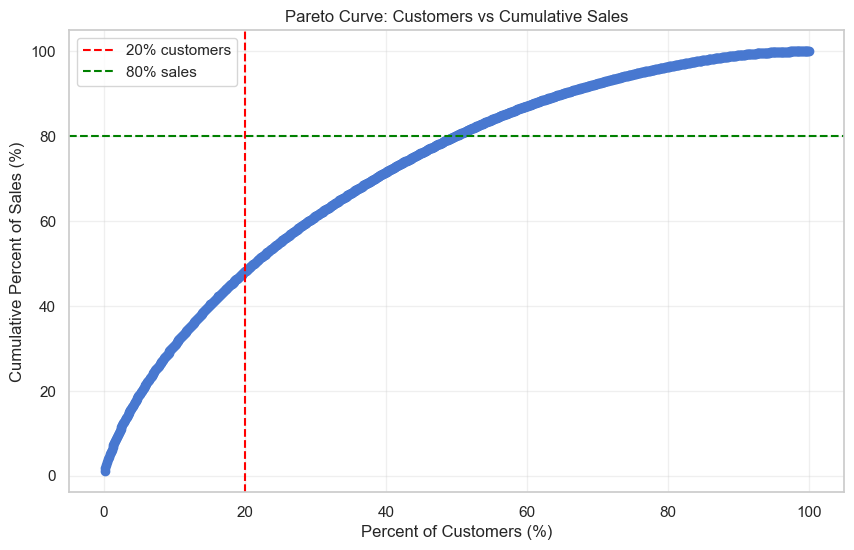

Top 20% customers contribute 48.0% of total sales


In [12]:
#  Top 20 customers by Sales
cust_sales = df.groupby(['Customer ID','Customer Name'])['Sales'].sum().sort_values(ascending=False).reset_index()
display(cust_sales.head(20))

# Cumulative curve for sales by customers
cust_sales['cum_sales'] = cust_sales['Sales'].cumsum()
total_sales = cust_sales['Sales'].sum()
cust_sales['cum_sales_pct'] = cust_sales['cum_sales'] / total_sales
cust_sales['cust_pct'] = (np.arange(1, len(cust_sales)+1) / len(cust_sales)) * 100

plt.figure(figsize=(10,6))
plt.plot(cust_sales['cust_pct'], cust_sales['cum_sales_pct']*100, marker='o')
plt.axvline(20, color='red', linestyle='--', label='20% customers')
plt.axhline(80, color='green', linestyle='--', label='80% sales')
plt.xlabel('Percent of Customers (%)')
plt.ylabel('Cumulative Percent of Sales (%)')
plt.title('Pareto Curve: Customers vs Cumulative Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

top20cust_count = int(0.2 * len(cust_sales))
sales_from_top20 = cust_sales.loc[:top20cust_count-1, 'Sales'].sum()
print(f"Top 20% customers contribute {sales_from_top20/total_sales*100:.1f}% of total sales")


In [13]:
# Strategic recommendations based on findings

# Top states to prioritize by sales
priority_states = state_sales.head(10)
print("States to prioritize by Sales (top 10):")
display(priority_states)

# Top cities to prioritize by profit and sales overlap
priority_cities = list(set(top20_cities_sales.head(10).index).union(set(top20_cities_profit.head(10).index)))
print("Cities to prioritize (union of top sales/profit):", priority_cities[:20])

print("\nRecommendations:")
print("1. Focus marketing & promotions in the top revenue states (shown above).")
print("2. For New York and California: CA may have higher/lower profit margin — run category-level discount tests before scaling discounts.")
print("3. Implement VIP/retention programs for top 20% customers (they drive a large share of sales/profit).")
print("4. Investigate cities in the top-20 lists with low profit margins for cost/repricing optimization.")
print("5. Limit blanket high discounts (>20%) where we observe frequent losses; test controlled promotions instead.")


States to prioritize by Sales (top 10):


State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

Cities to prioritize (union of top sales/profit): ['Chicago', 'Minneapolis', 'Lafayette', 'Jackson', 'Jacksonville', 'Houston', 'Atlanta', 'San Diego', 'Springfield', 'New York City', 'Los Angeles', 'Philadelphia', 'Seattle', 'San Francisco', 'Detroit']

Recommendations:
1. Focus marketing & promotions in the top revenue states (shown above).
2. For New York and California: CA may have higher/lower profit margin — run category-level discount tests before scaling discounts.
3. Implement VIP/retention programs for top 20% customers (they drive a large share of sales/profit).
4. Investigate cities in the top-20 lists with low profit margins for cost/repricing optimization.
5. Limit blanket high discounts (>20%) where we observe frequent losses; test controlled promotions instead.


In [14]:
state_sales.head(50).to_csv("state_sales_summary.csv")
state_summary.head(50).to_csv("state_profit_margin_summary.csv")
top20_cities_sales.to_csv("top20_cities_sales.csv")
top20_cities_profit.to_csv("top20_cities_profit.csv")
cust_sales.head(200).to_csv("customer_sales_ranking.csv")
cust_profit.head(200).to_csv("customer_profit_ranking.csv")

